In [1]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from tqdm import tqdm

In [2]:
# Cấu hình đường dẫn
BASE_DIR = 'data/processed'
GRAY_DIR = os.path.join(BASE_DIR, 'gray')
MASK_DIR = os.path.join(BASE_DIR, 'mask')
SAVE_DIR = 'data/features' # Thư mục để lưu đặc trưng HOG

# Tạo thư mục lưu nếu chưa tồn tại
os.makedirs(SAVE_DIR, exist_ok=True)

# Các nhãn (labels)
CATEGORIES = ['fist', 'two', 'palm']

# Tham số HOG 
# Ảnh 224x224 chia cho 8x8 cell sẽ cho ra 28x28 cells
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

In [3]:
def extract_hog_features(data_dir, categories):
    """
    Hàm đọc ảnh từ thư mục và trích xuất đặc trưng HOG.
    Trả về ma trận đặc trưng X và vector nhãn y.
    """
    features = []
    labels = []
    hog_images = []
    
    print(f"Đang xử lý dữ liệu tại: {data_dir}")
    
    for label_idx, category in enumerate(categories):
        class_dir = os.path.join(data_dir, category)
        
        # Bỏ qua nếu không phải thư mục hợp lệ
        if not os.path.isdir(class_dir):
            continue
            
        # Lấy danh sách tên file ảnh
        image_files = os.listdir(class_dir)
        
        for img_name in tqdm(image_files, desc=f"Class '{category}'"):
            img_path = os.path.join(class_dir, img_name)
            
            # Đọc ảnh dạng grayscale (mask hay grayROI đều có thể đọc dạng này)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                print(f"Lỗi đọc ảnh: {img_path}")
                continue
                
            # Tính toán đặc trưng HOG
            # Vector 1D trả về đã được flatten để sẵn sàng cho SVM
            fd, hog_image = hog(img, 
                                orientations=HOG_ORIENTATIONS, 
                                pixels_per_cell=HOG_PIXELS_PER_CELL,
                                cells_per_block=HOG_CELLS_PER_BLOCK, 
                                visualize=True,
                                feature_vector=True)
            
            features.append(fd)
            labels.append(label_idx)
            hog_images.append(hog_image) # 3. Lưu ảnh visualize vào list
            
    # Chuyển đổi list sang numpy array để tối ưu hóa bộ nhớ và dễ dàng lưu trữ
    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int32), np.array(hog_images, dtype=np.float32)


In [4]:
# 1. Trích xuất cho Gray ROI
print("--- TRÍCH XUẤT ĐẶC TRƯNG HOG CHO GRAY ROI ---")
X_gray, y_gray, hog_images_gray = extract_hog_features(GRAY_DIR, CATEGORIES)

print(f"Kích thước X_gray: {X_gray.shape}") # Expected: (số_lượng_ảnh, số_chiều_vector_HOG)
print(f"Kích thước y_gray: {y_gray.shape}")
print(f"Kích thước hog_images_gray: {hog_images_gray.shape}")

# Lưu dữ liệu
gray_feat_path = os.path.join(SAVE_DIR, 'X_gray_hog.npy')
gray_label_path = os.path.join(SAVE_DIR, 'y_gray_hog.npy')
gray_hog_vis_path = os.path.join(SAVE_DIR, 'hog_images_gray.npy')

np.save(gray_feat_path, X_gray)
np.save(gray_label_path, y_gray)
np.save(gray_hog_vis_path, hog_images_gray)
print(f"Đã lưu thành công đặc trưng Gray ROI tại {SAVE_DIR}!\n")

--- TRÍCH XUẤT ĐẶC TRƯNG HOG CHO GRAY ROI ---
Đang xử lý dữ liệu tại: data/processed\gray


Class 'palm': 100%|██████████| 750/750 [01:40<00:00,  7.48it/s]


Kích thước X_gray: (2250, 26244)
Kích thước y_gray: (2250,)
Kích thước hog_images_gray: (2250, 224, 224)
Đã lưu thành công đặc trưng Gray ROI tại data/features!



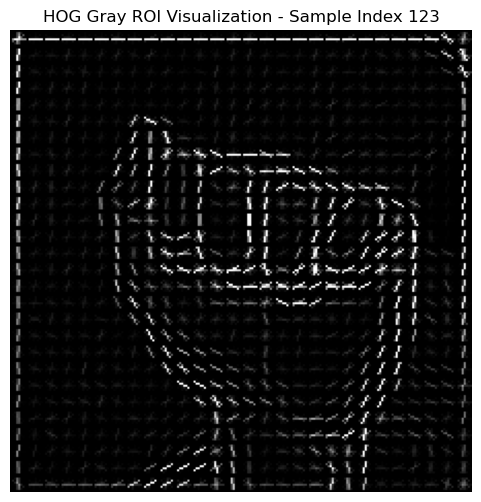

In [11]:
# Visualize một ảnh HOG từ tập Gray ROI
import matplotlib.pyplot as plt
from skimage import exposure

# (Tùy chọn) Load lại dữ liệu từ file nếu đã tắt kernel:
# hog_images_gray = np.load(os.path.join(SAVE_DIR, 'vis_gray_hog.npy'))

# Chọn index của ảnh bạn muốn hiển thị
index_to_show = 123

# Lấy ảnh HOG từ mảng
hog_img = hog_images_gray[index_to_show]

# Tăng cường độ sáng (rescale intensity) để các đường HOG hiển thị rõ nét hơn
hog_image_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

# Hiển thị ảnh
plt.figure(figsize=(6, 6))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title(f"HOG Gray ROI Visualization - Sample Index {index_to_show}")
plt.axis("off")
plt.show()

In [7]:
# 2. Trích xuất cho Mask ROI
print("--- TRÍCH XUẤT ĐẶC TRƯNG HOG CHO MASK ROI ---")
X_mask, y_mask, hog_images_mask = extract_hog_features(MASK_DIR, CATEGORIES)

print(f"Kích thước X_mask: {X_mask.shape}")
print(f"Kích thước y_mask: {y_mask.shape}")
print(f"Kích thước hog_images_mask: {hog_images_mask.shape}")

# Lưu dữ liệu
mask_feat_path = os.path.join(SAVE_DIR, 'X_mask_hog.npy')
mask_label_path = os.path.join(SAVE_DIR, 'y_mask_hog.npy')
mask_hog_vis_path = os.path.join(SAVE_DIR, 'hog_images_mask.npy')

np.save(mask_feat_path, X_mask)
np.save(mask_label_path, y_mask)
np.save(mask_hog_vis_path, hog_images_mask)
print(f"Đã lưu thành công đặc trưng Mask ROI tại {SAVE_DIR}!")

--- TRÍCH XUẤT ĐẶC TRƯNG HOG CHO MASK ROI ---
Đang xử lý dữ liệu tại: data/processed\mask


Class 'palm': 100%|██████████| 750/750 [01:41<00:00,  7.35it/s]


Kích thước X_mask: (2250, 26244)
Kích thước y_mask: (2250,)
Kích thước hog_images_mask: (2250, 224, 224)
Đã lưu thành công đặc trưng Mask ROI tại data/features!


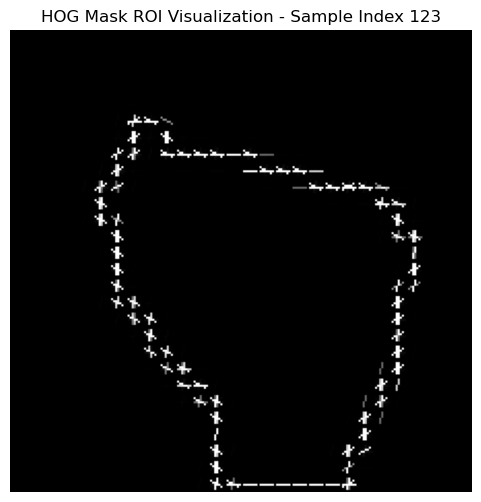

In [12]:
#Visualize một ảnh HOG từ tập Mask ROI
# (Tùy chọn) Load lại dữ liệu từ file nếu đã tắt kernel:
# hog_images_mask = np.load(os.path.join(SAVE_DIR, 'vis_mask_hog.npy'))

index_to_show = 123

# Lấy ảnh HOG từ mảng
hog_img = hog_images_mask[index_to_show]

# Tăng cường độ sáng (rescale intensity) để các đường HOG hiển thị rõ nét hơn
hog_image_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

# Hiển thị ảnh
plt.figure(figsize=(6, 6))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title(f"HOG Mask ROI Visualization - Sample Index {index_to_show}")
plt.axis("off")
plt.show()

In [3]:
import os
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib
import matplotlib.pyplot as plt


display_labels = ['Fist', 'Two', 'Palm']

In [4]:
# Đường dẫn dữ liệu
FEATURE_DIR = 'data/features'
MODEL_DIR = 'models'

# Tạo thư mục lưu model nếu chưa có
os.makedirs(MODEL_DIR, exist_ok=True)

# Load dữ liệu Gray ROI
X_gray = np.load(os.path.join(FEATURE_DIR, 'X_gray_hog.npy'))
y_gray = np.load(os.path.join(FEATURE_DIR, 'y_gray_hog.npy'))

# Load dữ liệu Mask ROI
X_mask = np.load(os.path.join(FEATURE_DIR, 'X_mask_hog.npy'))
y_mask = np.load(os.path.join(FEATURE_DIR, 'y_mask_hog.npy'))

print(f"Kích thước X_gray: {X_gray.shape}, y_gray: {y_gray.shape}")
print(f"Kích thước X_mask: {X_mask.shape}, y_mask: {y_mask.shape}")

Kích thước X_gray: (2250, 26244), y_gray: (2250,)
Kích thước X_mask: (2250, 26244), y_mask: (2250,)


In [5]:
# Chia tập train/test cho Gray ROI (80-20)
X_train_gray, X_test_gray, y_train_gray, y_test_gray = train_test_split(
    X_gray, y_gray, test_size=0.2, random_state=42, stratify=y_gray
)

# Chia tập train/test cho Mask ROI (80-20)
X_train_mask, X_test_mask, y_train_mask, y_test_mask = train_test_split(
    X_mask, y_mask, test_size=0.2, random_state=42, stratify=y_mask
)

print("--- Kích thước tập dữ liệu Gray ROI ---")
print(f"Train: {X_train_gray.shape}, Test: {X_test_gray.shape}")

print("\n--- Kích thước tập dữ liệu Mask ROI ---")
print(f"Train: {X_train_mask.shape}, Test: {X_test_mask.shape}")

--- Kích thước tập dữ liệu Gray ROI ---
Train: (1800, 26244), Test: (450, 26244)

--- Kích thước tập dữ liệu Mask ROI ---
Train: (1800, 26244), Test: (450, 26244)


In [ ]:
def train_and_evaluate_svm_gridsearch(X_train, X_test, y_train, y_test, model_save_path):

    # 1. Giữ nguyên Pipeline: StandardScaler -> SVM
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=42))
    ])

    # 2. Stratified 5 Fold Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 3. GridSearchCV với tune param_grid
    # Thay svc__ thành svm__ để khớp với tên ('svm') trong Pipeline
    param_grid = {
        'svm__C': [0.1, 1, 10],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto']
    }

    grid_search = GridSearchCV(
        estimator=svm_pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=2,      # tối đa số luồng CPU (-1) bị lỗi không hiện log
        verbose=2       # Hiển thị log trong quá trình tìm kiếm
    )

    # 4. Huấn luyện mô hình
    print("Đang tìm kiếm siêu tham số (GridSearchCV) và huấn luyện mô hình SVM...")
    grid_search.fit(X_train, y_train)

    # 5. Output: best_params_ và best_score_
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

    # 6. Sử dụng mô hình tốt nhất để dự đoán trên tập test
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Độ chính xác (Accuracy) trên tập test: {acc * 100:.2f}%")

    # 7. Output: classification_report
    print("\nChi tiết Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fist', 'Two', 'Palm']))

    # 8. Save model .pkl
    joblib.dump(best_model, model_save_path)
    print(f"\nĐã lưu mô hình tốt nhất tại: {model_save_path}\n")

    return best_model, y_pred

In [7]:
# Train cho tập Gray ROI với GridSearchCV
print("=== HUẤN LUYỆN SVM CHO TẬP GRAY ROI (GRIDSEARCH CV) ===")
gray_model_path = os.path.join(MODEL_DIR, 'svm_gray_pipeline.pkl')

svm_gray_best, y_pred_gray = train_and_evaluate_svm_gridsearch(
    X_train_gray, 
    X_test_gray, 
    y_train_gray, 
    y_test_gray, 
    gray_model_path
)

=== HUẤN LUYỆN SVM CHO TẬP GRAY ROI (GRIDSEARCH CV) ===
Đang tìm kiếm siêu tham số (GridSearchCV) và huấn luyện mô hình SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Cross-Validation Score: 99.94%
Độ chính xác (Accuracy) trên tập test: 100.00%

Chi tiết Classification Report:
              precision    recall  f1-score   support

        Fist       1.00      1.00      1.00       150
         Two       1.00      1.00      1.00       150
        Palm       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450


Đã lưu mô hình tốt nhất tại: models\svm_gray_pipeline.pkl\n


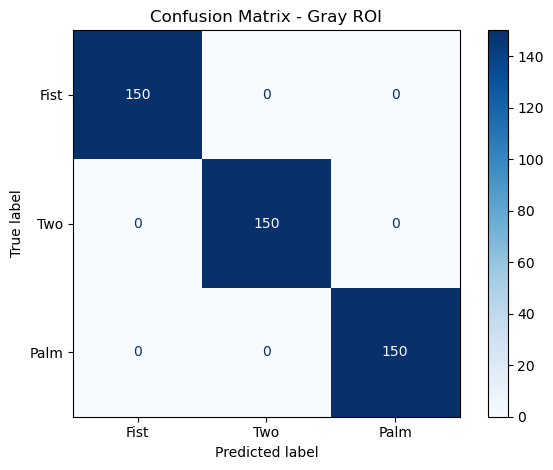

In [8]:
GrayROI_disp = ConfusionMatrixDisplay.from_predictions(
    y_test_gray, y_pred_gray, 
    display_labels=display_labels, 
    cmap=plt.cm.Blues,
)
GrayROI_disp.ax_.set_title('Confusion Matrix - Gray ROI')

plt.tight_layout()
plt.show()

In [9]:
# Train cho tập Mask ROI với GridSearchCV
print("=== HUẤN LUYỆN SVM CHO TẬP MASK ROI (GRIDSEARCH CV) ===")
mask_model_path = os.path.join(MODEL_DIR, 'svm_mask_pipeline.pkl')

svm_mask_best, y_pred_mask = train_and_evaluate_svm_gridsearch(
    X_train_mask, 
    X_test_mask, 
    y_train_mask, 
    y_test_mask, 
    mask_model_path
)

=== HUẤN LUYỆN SVM CHO TẬP MASK ROI (GRIDSEARCH CV) ===
Đang tìm kiếm siêu tham số (GridSearchCV) và huấn luyện mô hình SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Cross-Validation Score: 99.06%
Độ chính xác (Accuracy) trên tập test: 98.44%

Chi tiết Classification Report:
              precision    recall  f1-score   support

        Fist       0.99      0.99      0.99       150
         Two       0.98      0.99      0.99       150
        Palm       0.98      0.97      0.98       150

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450


Đã lưu mô hình tốt nhất tại: models\svm_mask_pipeline.pkl\n


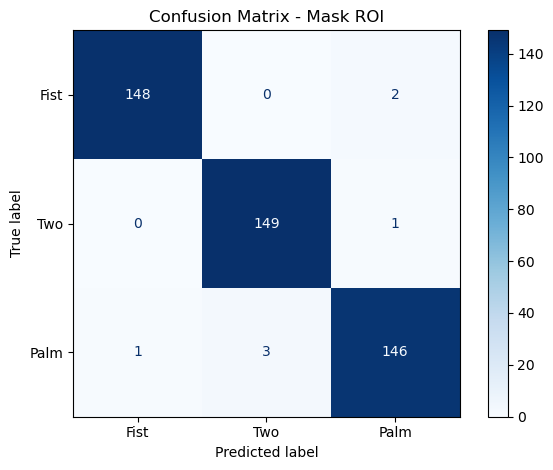

In [10]:
MaskROI_disp = ConfusionMatrixDisplay.from_predictions(
    y_test_mask, y_pred_mask, 
    display_labels=display_labels, 
    cmap=plt.cm.Blues,
)
MaskROI_disp.ax_.set_title('Confusion Matrix - Mask ROI')

plt.tight_layout()
plt.show()